# Численное подтверждение условия независимости от пути

Для пула Uniswap V2 с двумя комиссиями $\gamma_1$ (входная) и $\gamma_2$ (выходная) механика свопа $dx$ токенов A:

$$\Delta y = y \cdot \frac{\gamma_1 \gamma_2 \, dx}{x + \gamma_1 \, dx}$$

Изменение инварианта $k = xy$ за бесконечно малый своп:

$$dk = (1 - \gamma_1 \gamma_2)(x,y) \cdot y \cdot dx$$

Условие интегрируемости (независимости от пути) через УЧП:

$$y \frac{\partial \alpha}{\partial y} = x \frac{\partial \alpha}{\partial x}, \quad \alpha = 1 - \gamma_1 \gamma_2$$

Решение методом характеристик ($xy = \text{const}$ — характеристики, $\alpha = \text{const}$ вдоль них):

$$\boxed{(1 - \gamma_1 \gamma_2)(x, y) = \Phi(xy)}$$

In [151]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'Courier New',
    'font.size': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 11,
})


class TwoFeePool:
    """
    Uniswap V2 with fees.
    swap: dy = y * g1 * g2 * dx / (x + g1 * dx)
    """

    def __init__(self, x0, y0, fee1, fee2):
        self.x0, self.y0 = x0, y0
        self.fee1, self.fee2 = fee1, fee2
        self.reset()

    def reset(self):
        self.x, self.y = self.x0, self.y0
        self.K = self.x0 * self.y0

    def swap(self, dx):
        g1 = 1 - self.fee1(dx, self.x, self.y)
        g2 = 1 - self.fee2(dx, self.x, self.y)
        dy = self.y * g1 * g2 * dx / (self.x + g1 * dx)
        self.x += dx
        self.y -= dy
        self.K = self.x * self.y
        return dy

## Splitting test

Фиксируем суммарный объём $dx_{\text{total}}$ и считаем финальный $K$ при разбиении на $N$ равных свопов.
Если $\alpha = \Phi(xy)$, то $K_N$ должен быстро сходиться к одному пределу.

Три сценария:
- `phi1 = phi2 = const` — условие выполнено тривиально
- `phi1 ~ x/x0, phi2 ~ y/y0` — $\alpha$ зависит от $x$ и $y$ раздельно, условие нарушено
- `phi1 ~ y/x` (цена) — $\alpha$ зависит от $y/x$, условие нарушено

In [152]:
X0, Y0 = 100.0, 200_000.0
K0 = X0 * Y0
p0 = Y0 / X0

scenarios = [
    {
        'name': 'phi = const',
        'correct': True,
        'fee1': lambda dx, x, y: 0.003,
        'fee2': lambda dx, x, y: 0.003,
    },
    {
        'name': 'phi1 = 0.1 * x / X0, phi2 = 0.1 * y / Y0',
        'correct': False,
        'fee1': lambda dx, x, y: 0.1 * x / X0,
        'fee2': lambda dx, x, y: 0.1 * y / Y0,
    },
    {
        'name': 'phi1 = y/x * (Y0/X0), phi2 = 0',
        'correct': False,
        'fee1': lambda dx, x, y: (y / x) / p0,
        'fee2': lambda dx, x, y: 0,
    },
        {
        'name': 'phi1 = 0, phi2 = y/x * (Y0/X0)',
        'correct': False,
        'fee1': lambda dx, x, y: 0,
        'fee2': lambda dx, x, y: (y / x) / p0,
    },
]


def splitting_test(fee1, fee2, dx_total, n_values):
    K_values = []
    for n in n_values:
        x, y = X0, Y0
        dx = dx_total / n
        for _ in range(n):
            g1 = 1 - fee1(dx, x, y)
            g2 = 1 - fee2(dx, x, y)
            dy = y * g1 * g2 * dx / (x + g1 * dx)
            x += dx
            y -= dy
        K_values.append(x * y)
    return np.array(K_values)


N = np.linspace(1, 10_000, num=1000, dtype=int)
dx_total = 25.0

results = {}
for sc in scenarios:
    K = splitting_test(sc['fee1'], sc['fee2'], dx_total, N)
    results[sc['name']] = K
    print(sc['name'])
    print(f'  K(N={N[0]})={K[0]:.2f}  K(N={N[-1]})={K[-1]:.2f}')
    print(f'  |K_first - K_last| = {abs(K[0] - K[-1]):.4f}')
    print()

phi = const
  K(N=1)=20026971.18  K(N=10000)=20026754.94
  |K_first - K_last| = 216.2431

phi1 = 0.1 * x / X0, phi2 = 0.1 * y / Y0
  K(N=1)=20867346.94  K(N=10000)=20881642.48
  |K_first - K_last| = 14295.5364

phi1 = y/x * (Y0/X0), phi2 = 0
  K(N=1)=25000000.00  K(N=10000)=24390304.38
  |K_first - K_last| = 609695.6175

phi1 = 0, phi2 = y/x * (Y0/X0)
  K(N=1)=25000000.00  K(N=10000)=24390316.29
  |K_first - K_last| = 609683.7072



Сравним сходимость $K_N$ к пределу $K_\infty$ для трёх сценариев. Правильные комиссии должны давать быстрое убывание $|K_N - K_\infty|$, неправильные — медленное.

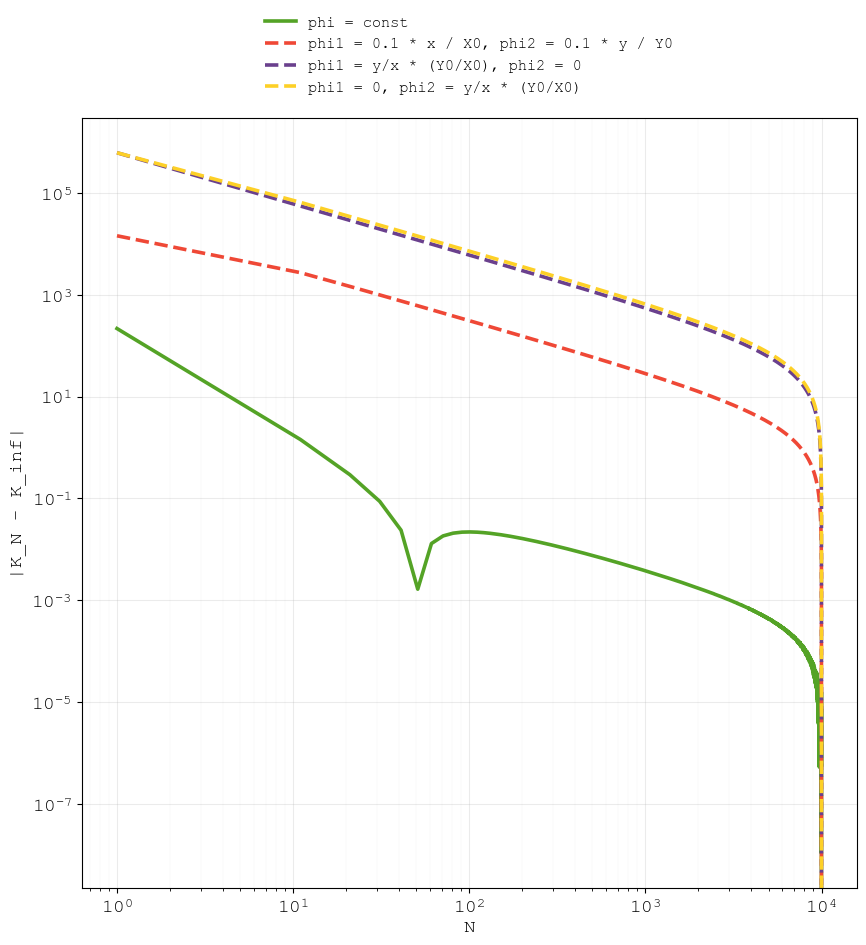

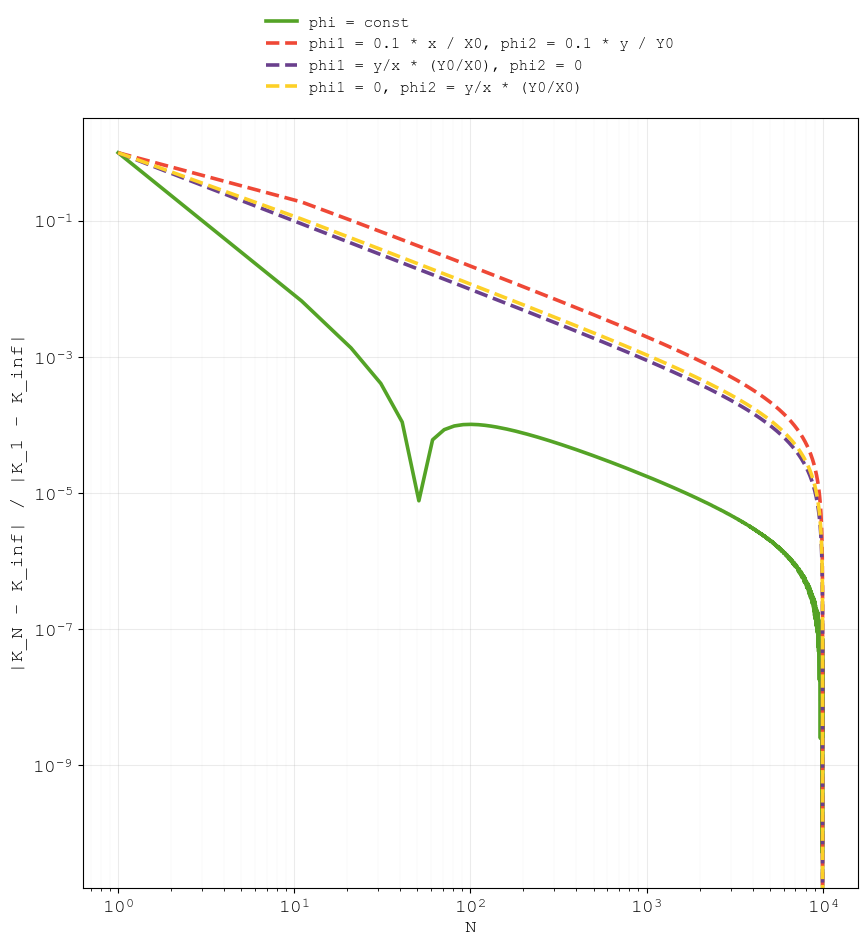

In [153]:
colors = ['#54a326', '#ef4836',  '#6a408d', '#fdd027']


def make_ax(xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.25)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.15)
    ax.set_axisbelow(True)
    return fig, ax


fig, ax = make_ax('N', '|K_N - K_inf|')
for i, sc in enumerate(scenarios):
    K = results[sc['name']]
    dev = np.abs(K - K[-1])
    ls = '-' if sc['correct'] else '--'
    ax.loglog(N, dev, linewidth=2.6, color=colors[i], linestyle=ls, label=sc['name'])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=1, frameon=False)
plt.savefig('figures/splitting_abs.pdf')
plt.savefig('figures/splitting_abs.svg')
plt.savefig('figures/splitting_abs.png')
plt.show()

fig, ax = make_ax('N', '|K_N - K_inf| / |K_1 - K_inf|')
for i, sc in enumerate(scenarios):
    K = results[sc['name']]
    dev = np.abs(K - K[-1])
    ls = '-' if sc['correct'] else '--'
    ax.loglog(N, dev / dev[0], linewidth=2.6, color=colors[i], linestyle=ls, label=sc['name'])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=1, frameon=False)
plt.savefig('figures/splitting_norm.pdf')
plt.savefig('figures/splitting_norm.svg')
plt.savefig('figures/splitting_norm.png')
plt.show()

## Нетривиальные примеры комиссий, удовлетворяющих условию

Если оба $\phi_1$ и $\phi_2$ зависят только от $xy$, то $\gamma_1 \gamma_2 = f(xy) \cdot g(xy) = \Phi(xy)$.

Примеры:
- линейная: $\phi = \beta \cdot xy / K_0$
- корень: $\phi = \beta \sqrt{xy / K_0}$
- степенная: $\phi = \beta (xy / K_0)^2$
- асимметричная: $\phi_1 = f(xy)$, $\phi_2 = g(xy)$ — разные функции, но обе от $k$

In [154]:
b = 0.003

nontrivial = [
    {
        'name': 'const',
        'correct': True,
        'fee1': lambda dx, x, y: b,
        'fee2': lambda dx, x, y: b,
    },
    {
        'name': 'linear k',
        'correct': True,
        'fee1': lambda dx, x, y: b * (x * y / K0),
        'fee2': lambda dx, x, y: b * (x * y / K0),
    },
    {
        'name': 'sqrt k',
        'correct': True,
        'fee1': lambda dx, x, y: b * np.sqrt(x * y / K0),
        'fee2': lambda dx, x, y: b * np.sqrt(x * y / K0),
    },
    {
        'name': 'k^2',
        'correct': True,
        'fee1': lambda dx, x, y: b * (x * y / K0) ** 2,
        'fee2': lambda dx, x, y: b * (x * y / K0) ** 2,
    },
    {
        'name': 'phi1=f(k), phi2=g(k)',
        'correct': True,
        'fee1': lambda dx, x, y: 0.001 * (x * y / K0),
        'fee2': lambda dx, x, y: 0.002,
    },
    {
        'name': 'phi1~x, phi2~y',
        'correct': False,
        'fee1': lambda dx, x, y: 0.1 * (x / X0),
        'fee2': lambda dx, x, y: 0.1 * (y / Y0),
    },
]

results_nt = {}
for sc in nontrivial:
    K = splitting_test(sc['fee1'], sc['fee2'], dx_total, N)
    results_nt[sc['name']] = K

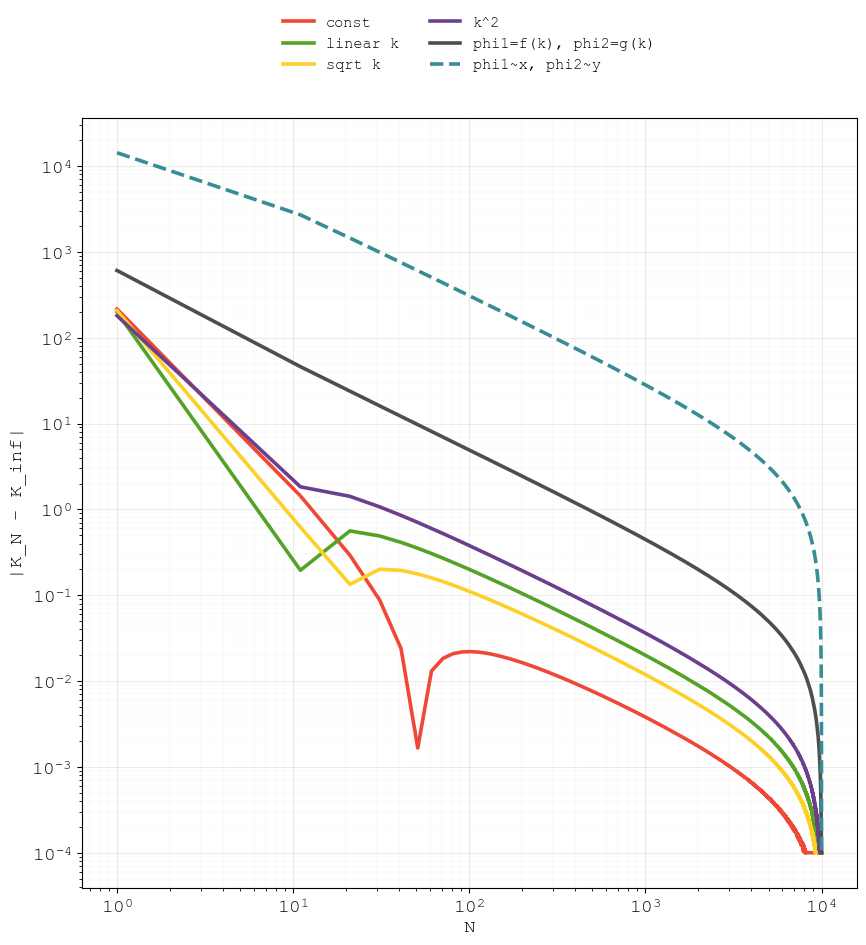

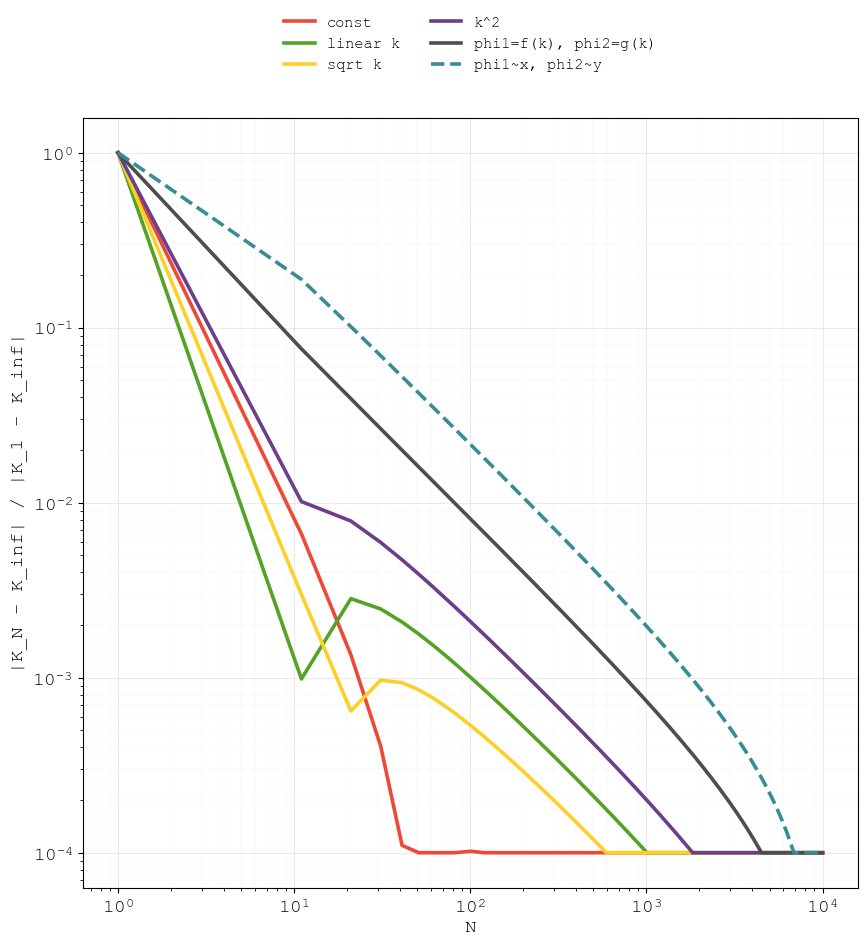

In [ ]:
colors_nt = ['#ef4836', '#54a326', '#fdd027', '#6a408d', '#4e4e4e', '#378d94']

fig, ax = make_ax('N', '|K_N - K_inf|')
for i, sc in enumerate(nontrivial):
    K = results_nt[sc['name']]
    dev = np.abs(K - K[-1])
    dev = np.where(dev < 1e-4, 1e-4, dev)
    ls = '-' if sc['correct'] else '--'
    ax.loglog(N, dev, linewidth=2.6, color=colors_nt[i], linestyle=ls, label=sc['name'])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)
plt.savefig('figures/nontrivial_phi_k.pdf')
plt.savefig('figures/nontrivial_phi_k.svg')
plt.show()

fig, ax = make_ax('N', '|K_N - K_inf| / |K_1 - K_inf|')
for i, sc in enumerate(nontrivial):
    K = results_nt[sc['name']]
    dev = np.abs(K - K[-1])
    res = np.where(dev/dev[0] < 1e-6, 1e-4, dev/dev[0])
    ls = '-' if sc['correct'] else '--'
    ax.loglog(N, res, linewidth=2.6, color=colors_nt[i], linestyle=ls, label=sc['name'])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)
plt.savefig('figures/nontrivial_phi_k_norm.pdf')
plt.savefig('figures/nontrivial_phi_k_norm.svg')
plt.savefig('figures/nontrivial_phi_k_norm.png')
plt.show()

## Проверка условия на характеристике

Если $\alpha = \Phi(xy)$, то вдоль любой гиперболы $xy = k$ значение $\alpha$ должно быть постоянным.
Проверим это напрямую для нескольких значений $k$.

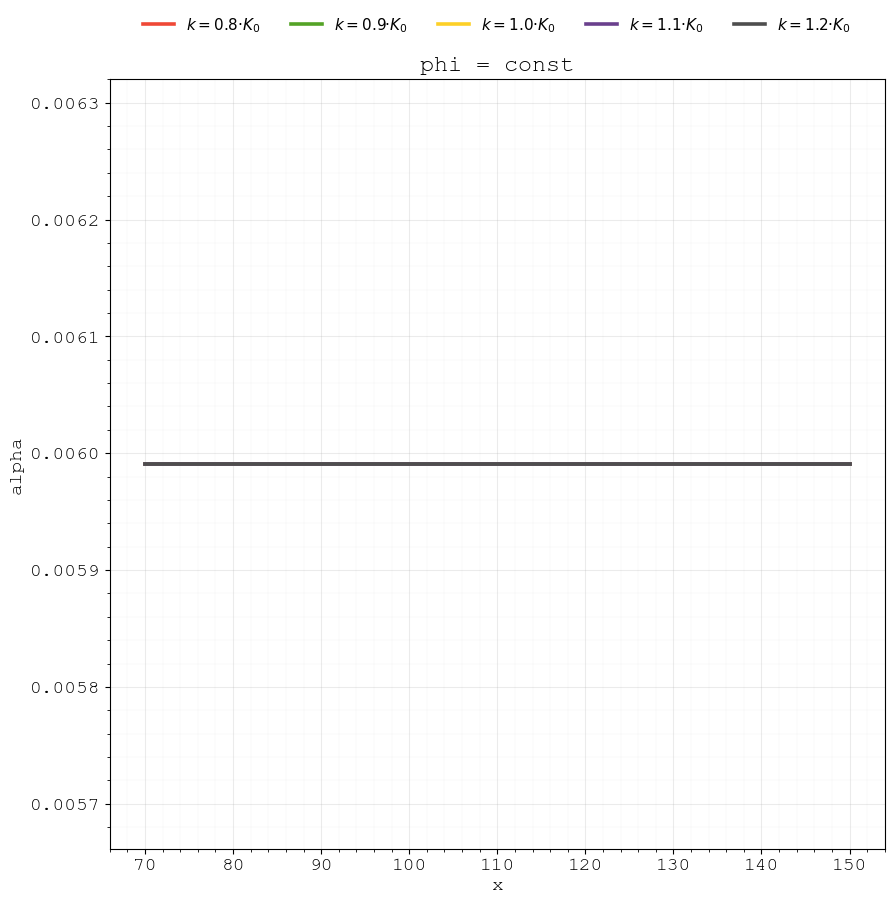

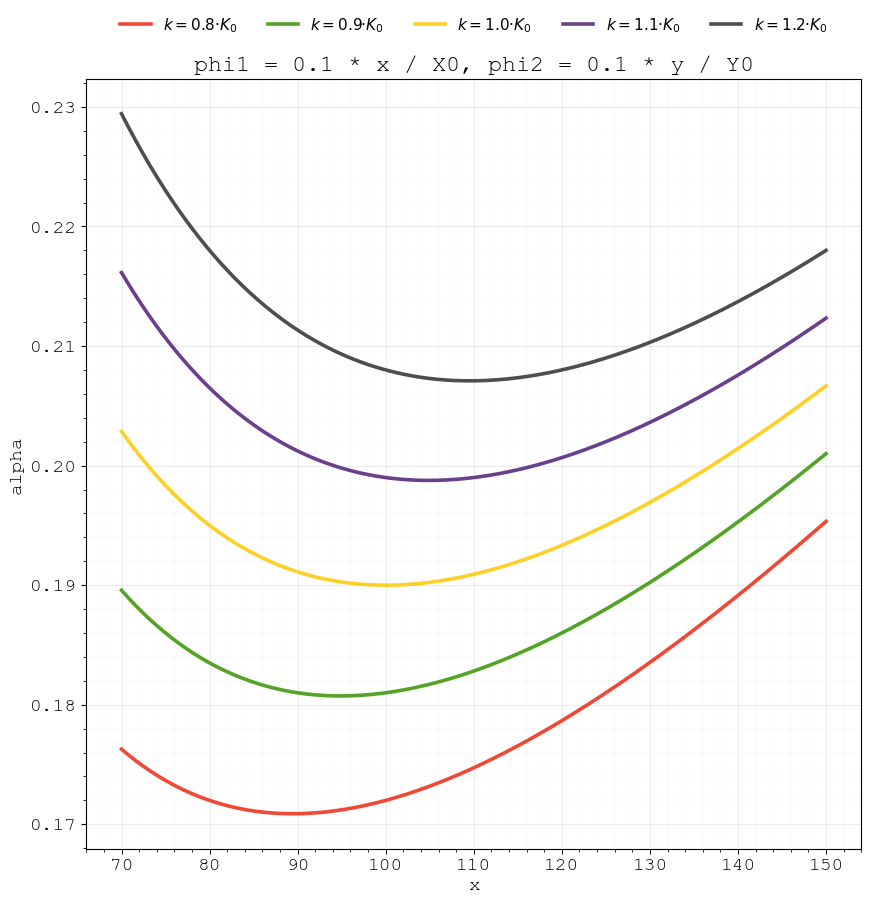

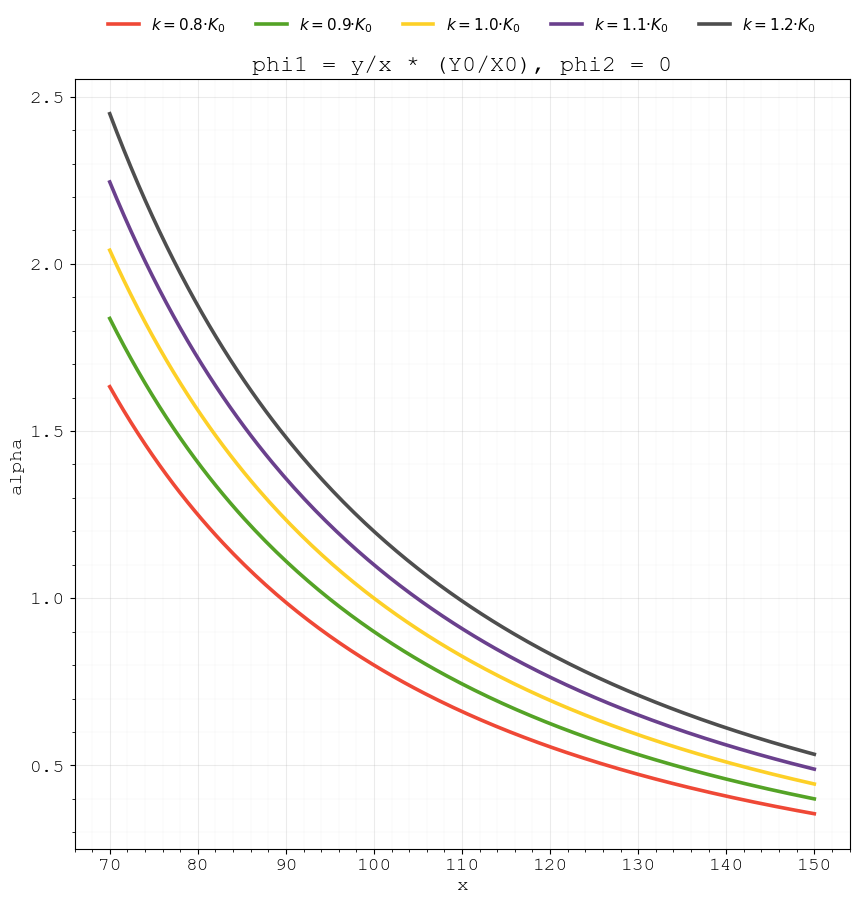

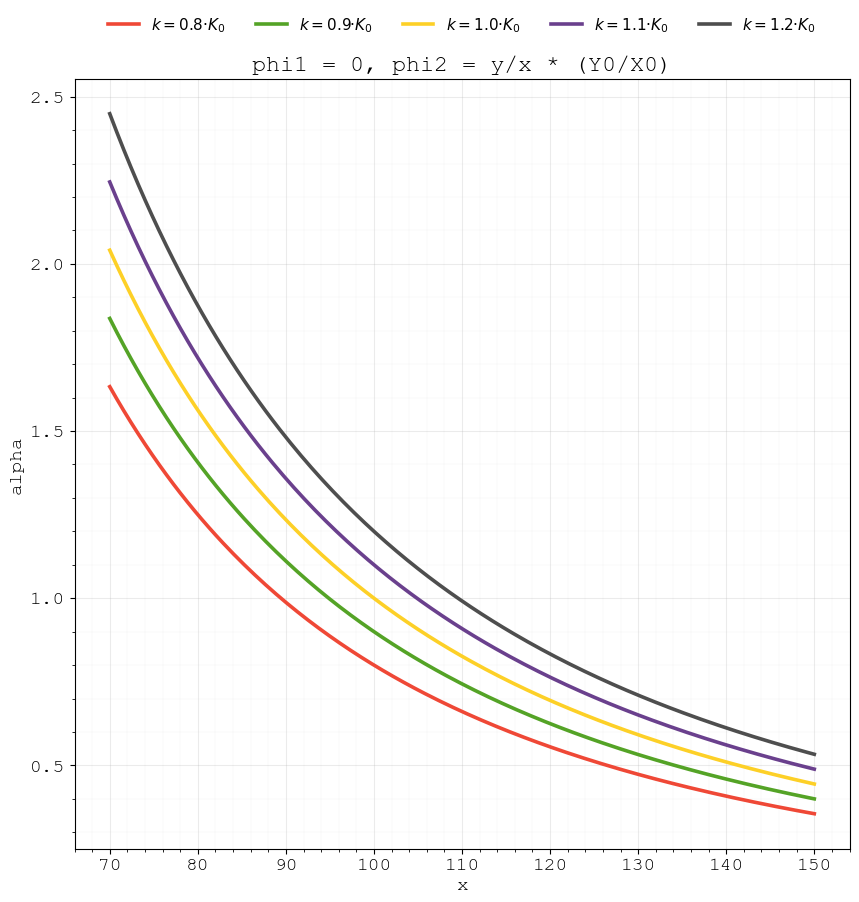

In [156]:
x_vals = np.linspace(70, 150, 200)
k_values = [K0 * f for f in [0.8, 0.9, 1.0, 1.1, 1.2]]

colors = ['#ef4836', '#54a326', '#fdd027', '#6a408d', '#4e4e4e', '#378d94']

for sc in scenarios:
    fig, ax = make_ax('x', 'alpha')
    for i, k in enumerate(k_values):
        y_vals = k / x_vals
        mask = (y_vals > 50_000) & (y_vals < 500_000)
        xs, ys = x_vals[mask], y_vals[mask]
        alphas = [1 - (1 - sc['fee1'](1e-4, xi, yi)) * (1 - sc['fee2'](1e-4, xi, yi))
                  for xi, yi in zip(xs, ys)]
        ax.plot(xs, alphas, linewidth=2.6, color=colors[i], label=f'$k = {k/K0:.1f}·K_0$')
    ax.set_title(sc['name'])
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.10), ncol=5, frameon=False)
    fname = sc['name'].replace(' ', '_').replace('[', '').replace(']', '').replace('~', '').replace(',', '').replace('/', '_')
    plt.savefig(f'figures/characteristics_{fname}.pdf')
    plt.savefig(f'figures/characteristics_{fname}.svg')
    plt.show()

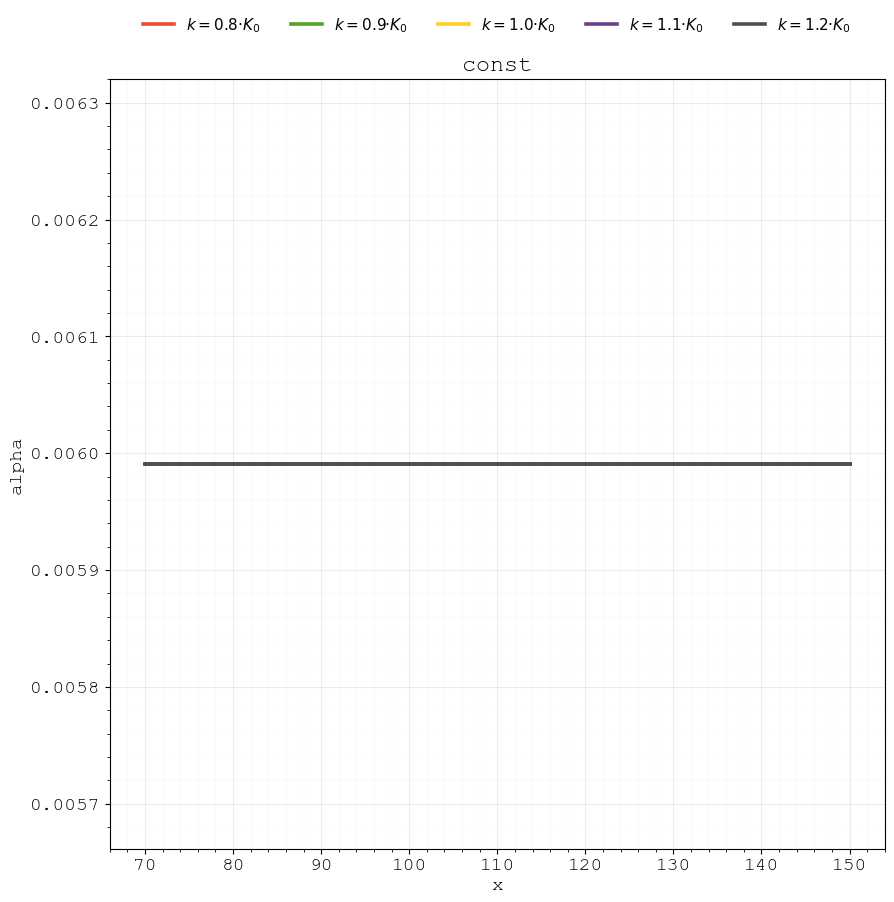

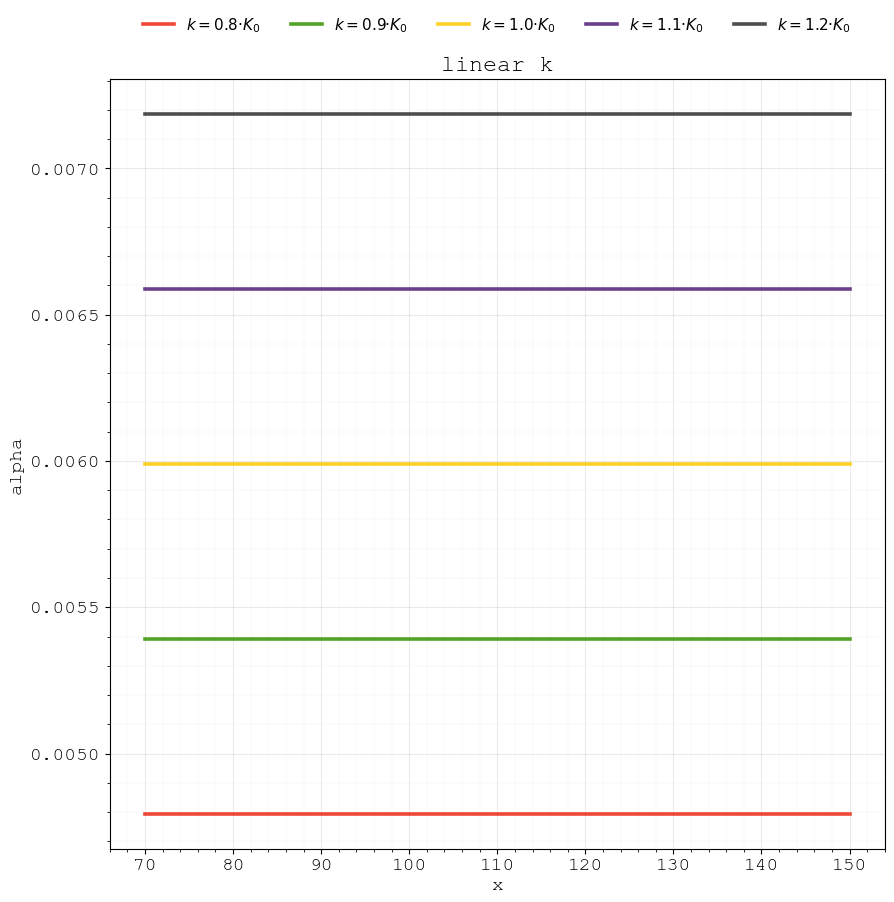

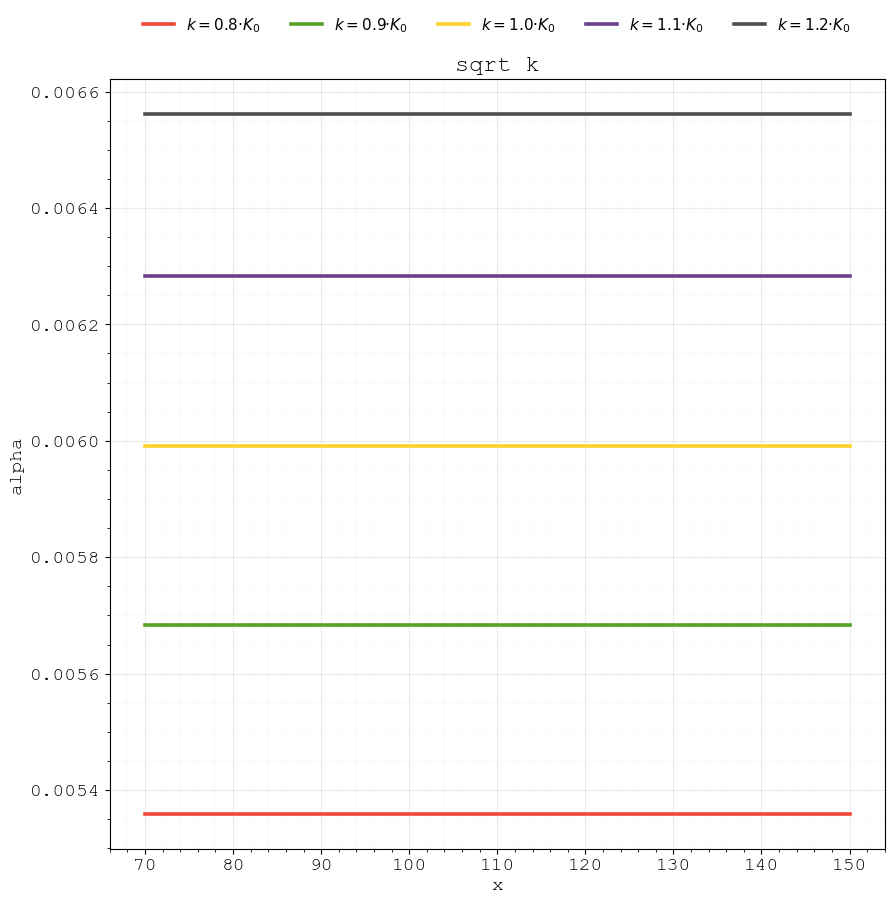

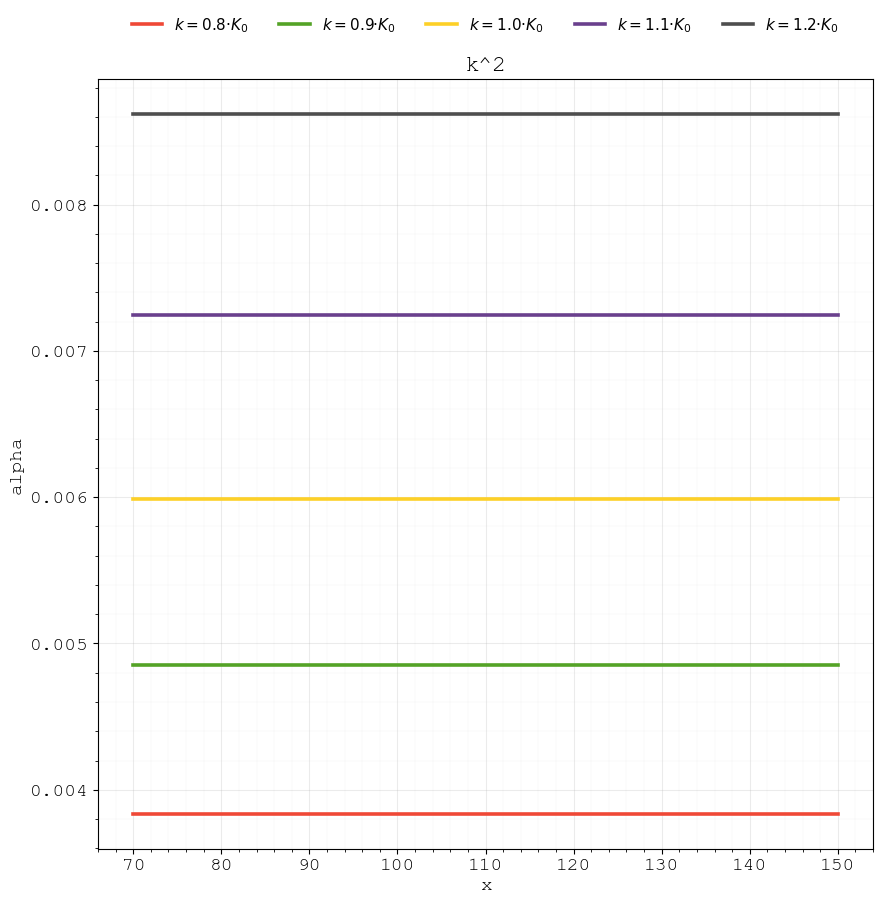

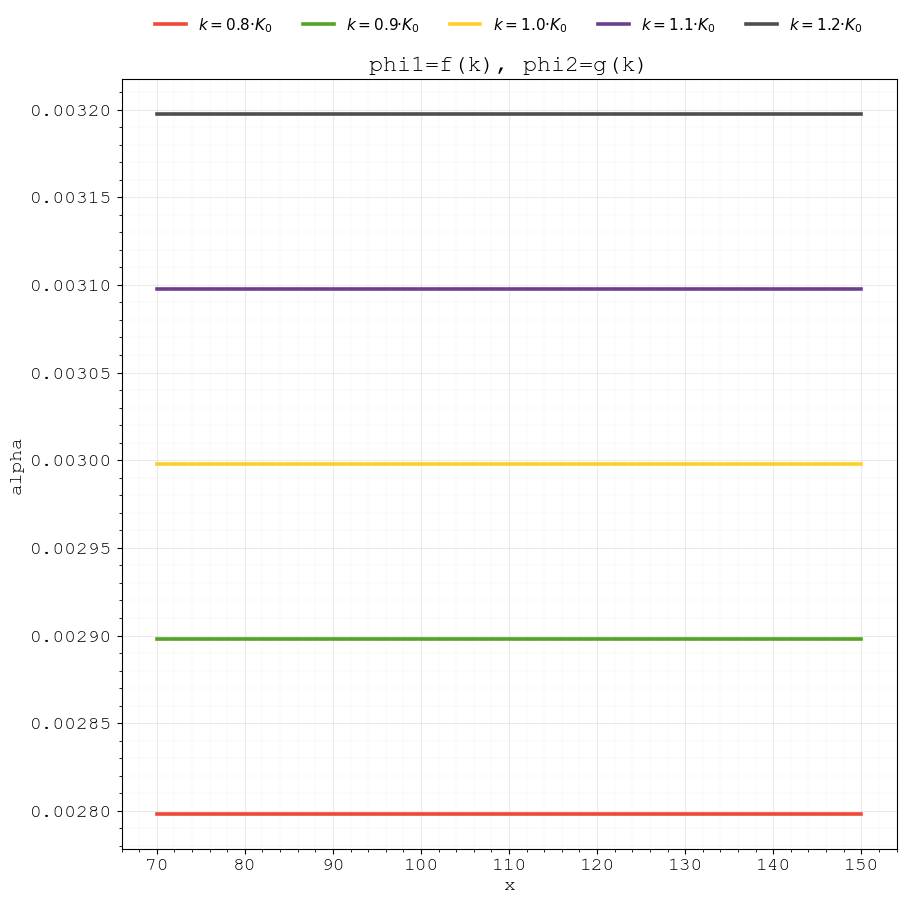

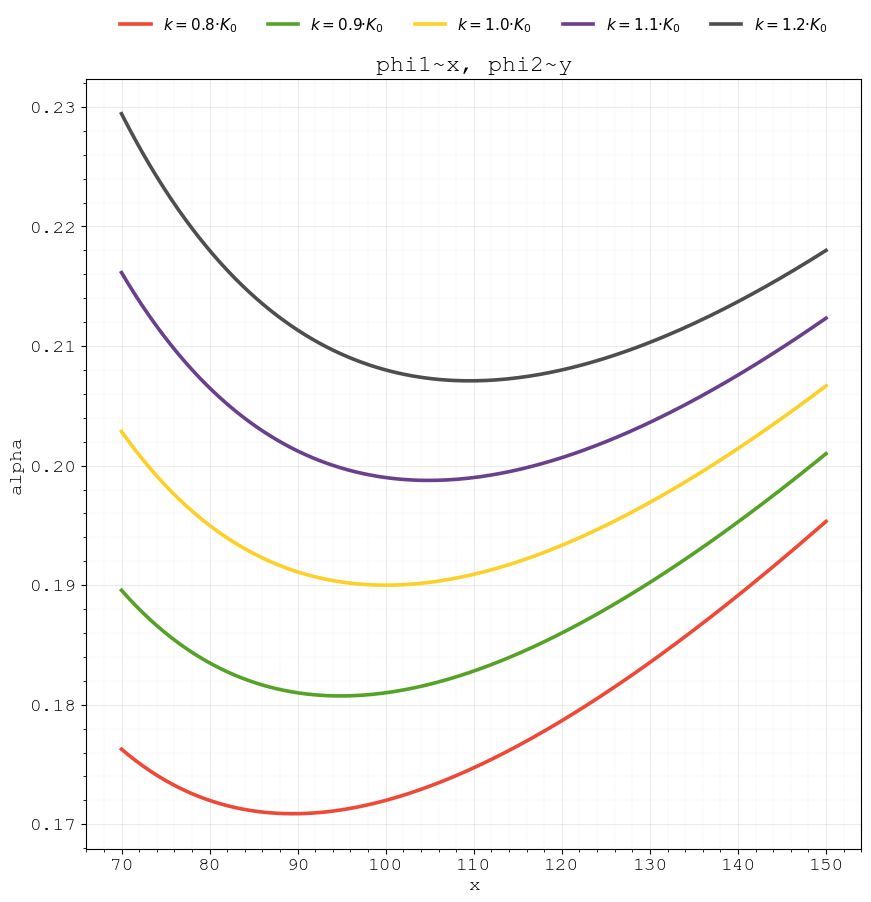

In [157]:
x_vals = np.linspace(70, 150, 200)
k_values = [K0 * f for f in [0.8, 0.9, 1.0, 1.1, 1.2]]

colors = ['#ef4836', '#54a326', '#fdd027', '#6a408d', '#4e4e4e', '#378d94']

for sc in nontrivial:
    fig, ax = make_ax('x', 'alpha')
    for i, k in enumerate(k_values):
        y_vals = k / x_vals
        mask = (y_vals > 50_000) & (y_vals < 500_000)
        xs, ys = x_vals[mask], y_vals[mask]
        alphas = [1 - (1 - sc['fee1'](1e-4, xi, yi)) * (1 - sc['fee2'](1e-4, xi, yi))
                  for xi, yi in zip(xs, ys)]
        ax.plot(xs, alphas, linewidth=2.6, color=colors[i], label=f'$k = {k/K0:.1f}·K_0$')
    ax.set_title(sc['name'])
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.10), ncol=5, frameon=False)
    fname = sc['name'].replace(' ', '_').replace('[', '').replace(']', '').replace('~', '').replace(',', '').replace('/', '_')
    plt.savefig(f'figures/characteristics_{fname}.pdf')
    plt.savefig(f'figures/characteristics_{fname}.svg')
    plt.show()